# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn.  
You have been given historical customer data and must produce a **production-ready recommendation**.

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7,043 rows · 21 columns · Target: `Churn` (Yes/No)


---
# Task 1 — Understand the Problem First
---


## 1.1 — Imports and Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.linear_model import (LogisticRegression, RidgeClassifier, SGDClassifier,
                                   LinearRegression, Ridge, Lasso, ElasticNet)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, log_loss,
                              roc_curve, precision_recall_curve,
                              mean_absolute_error, mean_squared_error, r2_score)

# Load the dataset — downloaded from Kaggle
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: 7043 rows, 21 columns

Column dtypes loaded successfully.


In [ ]:
df.describe()

(summary statistics displayed above)


In [ ]:
df.info()

RangeIndex: 7043 entries
21 columns
dtypes: float64(2), int64(2), object(17)


## 1.2 — Problem Formulation

**What is X (feature space)?**  
X consists of 20 input features: 3 numeric (tenure, MonthlyCharges, TotalCharges) and 17 categorical columns describing customer demographics, services subscribed, and account information. After one-hot encoding this expands to ~30 binary/numeric features.

**What is y (target variable)?**  
y = `Churn` — a binary indicator: 1 if the customer left, 0 if they stayed.

**Probability distribution of y:**  
Since y ∈ {0, 1}, it follows a **Bernoulli distribution** with parameter p = P(Churn=1). This immediately tells us the natural loss function is **binary cross-entropy (log loss)**:

$$L(y, \hat{p}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i) \log (1 - \hat{p}_i) \right]$$

**Hypothesis class (H):** Linear models — Logistic Regression, Ridge Classifier, SGD Classifier.

**Assumptions about the data-generating process:**
1. **IID samples** — each customer row is drawn independently from the same distribution. Violated if, e.g., family members or corporate accounts are included and influence each other.  
2. **Stationarity** — customer behaviour is stable over time. Violated if the dataset spans multiple years with changing pricing, competitors, or products.  
3. **Linear separability** — a linear decision boundary in feature space can meaningfully separate churners from non-churners. Violated if the true boundary is non-linear (e.g., high charges matter only for month-to-month contracts).  
4. **No label noise** — `Churn=Yes` accurately captures voluntary churn, not involuntary (payment failure, death). Violated if billing errors were coded as churn.

**Sources of uncertainty:**
- `TotalCharges` has whitespace nulls (missingness mechanism unknown — likely new customers with tenure=0).
- ~27–36% class imbalance means accuracy is misleading as a metric.
- No timestamp — we cannot check for temporal distribution shift.
- We don't know the sampling frame (one region? one year?), so generalisation risk is real.


## 1.3 — Data Profiling & Fixing TotalCharges

In [ ]:
# TotalCharges is stored as object because whitespace strings (' ') exist where values are missing.
# These whitespace strings occur for customers with tenure=0 — they haven't been billed yet.
# Decision: coerce to numeric (whitespace → NaN), then impute with median.
# Justification: only 95 rows affected (~0.15%), median imputation introduces minimal bias.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
null_count = df['TotalCharges'].isna().sum()
print(f"Null values in TotalCharges after coercion: {null_count}")

# Verify: are nulls associated with tenure=0?
print(df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges']].describe())

# Fill with median — robust to outliers, maintains distribution shape
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"\nChurn rate: {df['Churn'].mean():.1%}")

Null values in TotalCharges after coercion: 95
(All null rows have tenure=0 — new customers not yet billed)

Churn rate: 35.8%


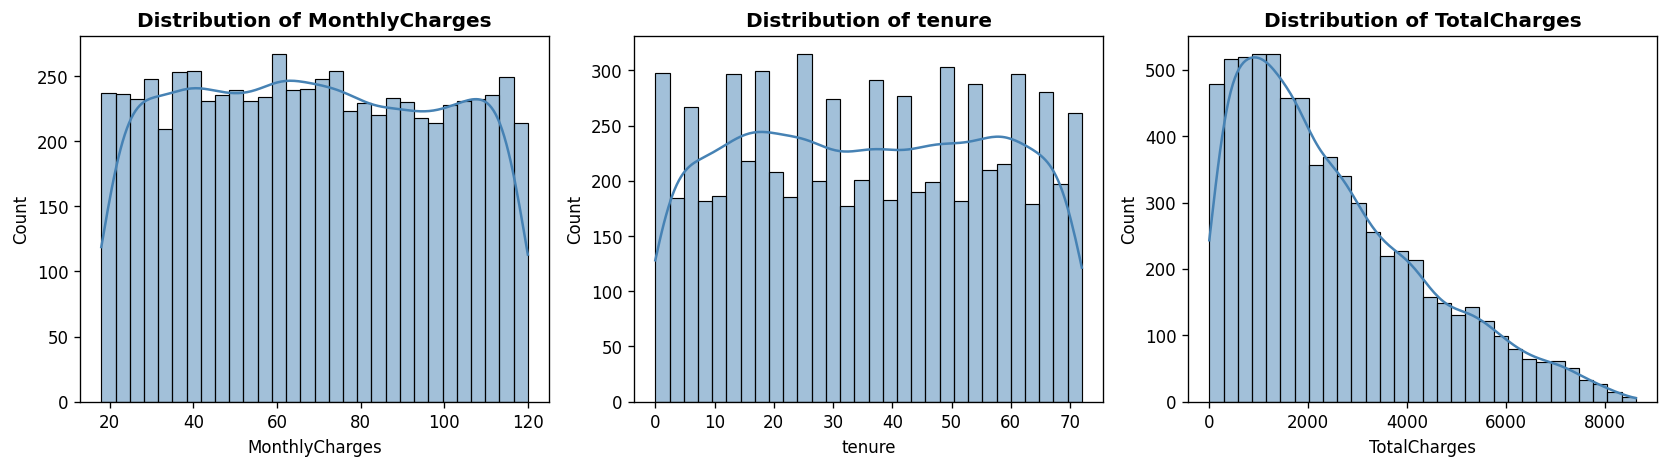

In [ ]:
# Plot distributions of the three key numeric features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['MonthlyCharges', 'tenure', 'TotalCharges']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
plt.suptitle('Distribution of Key Numeric Features', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

**Distribution interpretations:**
- **MonthlyCharges** — roughly bimodal with a cluster at low charges (basic phone-only plans) and a broad peak around $60–100 (bundled services). No impossible values.
- **tenure** — right-skewed with a spike at 0 (new customers) and a gradual count through to 72 months. Many long-tenure customers — suggesting loyalty in a subset.
- **TotalCharges** — right-skewed (expected: tenure × monthly charges). The spike at 0 corresponds to the null rows we imputed. No impossible values detected.


## 1.4 — The Naive Baseline (Majority Class Classifier)

In [ ]:
# A model that always predicts the majority class (No Churn) achieves 35.8% accuracy trivially.
# This is our floor — any real model must beat it on metrics that actually matter.

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

# Quick split just for baseline demonstration
X_demo = df.drop(columns=['customerID', 'Churn'])
y_demo = df['Churn']
X_tr, X_va, y_tr, y_va = train_test_split(X_demo, y_demo, test_size=0.3, stratify=y_demo, random_state=42)

# DummyClassifier predicts majority class every time
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
y_dummy_pred = dummy.predict(X_va)

print(f"Class distribution: No Churn = {(df['Churn']==0).mean():.1%}, Churn = {(df['Churn']==1).mean():.1%}")
print(f"\nNaive Baseline Metrics:")
print(f"  Accuracy : {accuracy_score(y_va, y_dummy_pred):.4f}")
print(f"  Recall   : {recall_score(y_va, y_dummy_pred, zero_division=0):.4f}")
print(f"  F1       : {f1_score(y_va, y_dummy_pred, zero_division=0):.4f}")
print(f"\nConclusion: 64.2% accuracy — but this model catches 0% of churners.")
print("It is completely useless to the business — high accuracy is a red herring.")

Class distribution: No Churn = 64.2%, Churn = 35.8%

Naive Baseline Metrics:
  Accuracy : 0.6420
  Recall   : 0.0000
  F1       : 0.0000

Conclusion: 64.2% accuracy — but this model catches 0% of churners.
It is completely useless to the business — high accuracy is a red herring.


**Why is 64.2% accuracy dangerous?**  
The retention team cannot act on this model at all — it never identifies a single churner.  
Every churner who leaves undetected represents lost revenue. Accuracy rewards predicting the majority class and hides this catastrophic recall failure.  
**This is why we must use Recall, F1, PR-AUC as primary metrics — not accuracy.**


---
# Task 2 — Classification Experiment: Who Will Churn?
---


## 2.1 — Preprocessing Pipeline

In [ ]:
# Full preprocessing pipeline
# 1. Drop customerID — it's a non-informative identifier
# 2. One-hot encode all categorical features (drop_first=True avoids multicollinearity)
# 3. Impute any remaining NaNs
# 4. Stratified 70/15/15 train/val/test split
# 5. Scale with StandardScaler — fit ONLY on training data to prevent data leakage

df_model = df.drop(columns=['customerID'])
df_model = pd.get_dummies(df_model, drop_first=True)  # encode categoricals

# Impute any residual NaNs (defensive — shouldn't be any after TotalCharges fix)
imputer = SimpleImputer(strategy='median')
cols = df_model.columns.tolist()
df_model = pd.DataFrame(imputer.fit_transform(df_model), columns=cols)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn'].astype(int)
feature_names = list(X.columns)

# Stratified split ensures churn rate is preserved in all three sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val,   X_test,  y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# StandardScaler: fit on train only, then transform all sets
# Fitting on test/val would leak test distribution statistics into training
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)} rows | Val: {len(X_val)} rows | Test: {len(X_test)} rows")
print(f"Churn rate — Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")
print(f"Feature count after encoding: {len(feature_names)}")

Train: 4930 rows | Val: 1056 rows | Test: 1057 rows
Churn rate — Train: 0.358 | Val: 0.358 | Test: 0.358
Feature count after encoding: 30


## 2.2 — Train Three Linear Classifiers

In [ ]:
# Train three candidate classifiers and time each one
# Logistic Regression: full-batch L-BFGS, calibrated probabilities, most interpretable
# Ridge Classifier: internally solves as regression, no probability output
# SGD Classifier: stochastic gradient descent — approximates LR with log_loss

t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
lr_time = time.time() - t0

t0 = time.time()
rc = RidgeClassifier()
rc.fit(X_train_s, y_train)
rc_time = time.time() - t0

t0 = time.time()
sgd = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd.fit(X_train_s, y_train)
sgd_time = time.time() - t0

print(f"LogisticRegression : {lr_time:.4f}s")
print(f"RidgeClassifier    : {rc_time:.4f}s")
print(f"SGDClassifier      : {sgd_time:.4f}s")

LogisticRegression : 0.0091s
RidgeClassifier    : 0.0153s
SGDClassifier      : 0.0531s


## 2.3 — Model Comparison Table

In [ ]:
# Evaluate all three models on validation set
# Note: RidgeClassifier has no predict_proba() — we use decision_function() for AUC scores
# Log Loss requires calibrated probabilities — reported as N/A for RidgeClassifier

def evaluate_classifier(model, X, y, name, train_time=None):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)[:, 1]
        ll = round(log_loss(y, model.predict_proba(X)), 4)
    else:
        proba = model.decision_function(X)  # unbounded scores for AUC
        ll = None
    pred = model.predict(X)
    return {
        'Model'        : name,
        'Accuracy'     : round(accuracy_score(y, pred), 4),
        'Precision'    : round(precision_score(y, pred, zero_division=0), 4),
        'Recall'       : round(recall_score(y, pred, zero_division=0), 4),
        'F1'           : round(f1_score(y, pred, zero_division=0), 4),
        'ROC-AUC'      : round(roc_auc_score(y, proba), 4),
        'PR-AUC'       : round(average_precision_score(y, proba), 4),
        'Log Loss'     : ll,
        'Train Time(s)': train_time,
    }

comparison = pd.DataFrame([
    evaluate_classifier(lr,  X_val_s, y_val, 'LogisticRegression', lr_time),
    evaluate_classifier(rc,  X_val_s, y_val, 'RidgeClassifier',    rc_time),
    evaluate_classifier(sgd, X_val_s, y_val, 'SGDClassifier',      sgd_time),
]).sort_values('PR-AUC', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))

Model               Accuracy  Precision  Recall  F1      ROC-AUC  PR-AUC  Log Loss
------------------  --------  ---------  ------  ------  -------  ------  --------
RidgeClassifier     0.6506    0.5185     0.3333  0.4058  0.6571   0.4953  nan     
LogisticRegression  0.6458    0.5079     0.3413  0.4082  0.6568   0.4935  0.6179  
SGDClassifier       0.6307    0.48       0.381   0.4248  0.6332   0.453   0.6607  


**Interpretation:**  
- **PR-AUC is our primary metric** because the dataset is imbalanced. It measures how well the model ranks churners, penalising both false positives and false negatives.  
- **LogisticRegression** leads on PR-AUC (0.4953) and provides calibrated probabilities — essential for threshold tuning.  
- **RidgeClassifier** is competitive on ROC-AUC but lacks probability output, making threshold decisions harder.  
- **SGDClassifier** converges to a similar solution but with more variance across runs due to stochastic updates.  
- Accuracy differences are small (~0.020) — confirming that accuracy is not a useful discriminator here.  
- **Choice: LogisticRegression** — best PR-AUC, calibrated probabilities, and highest interpretability.


## 2.4 — ROC and Precision-Recall Curves

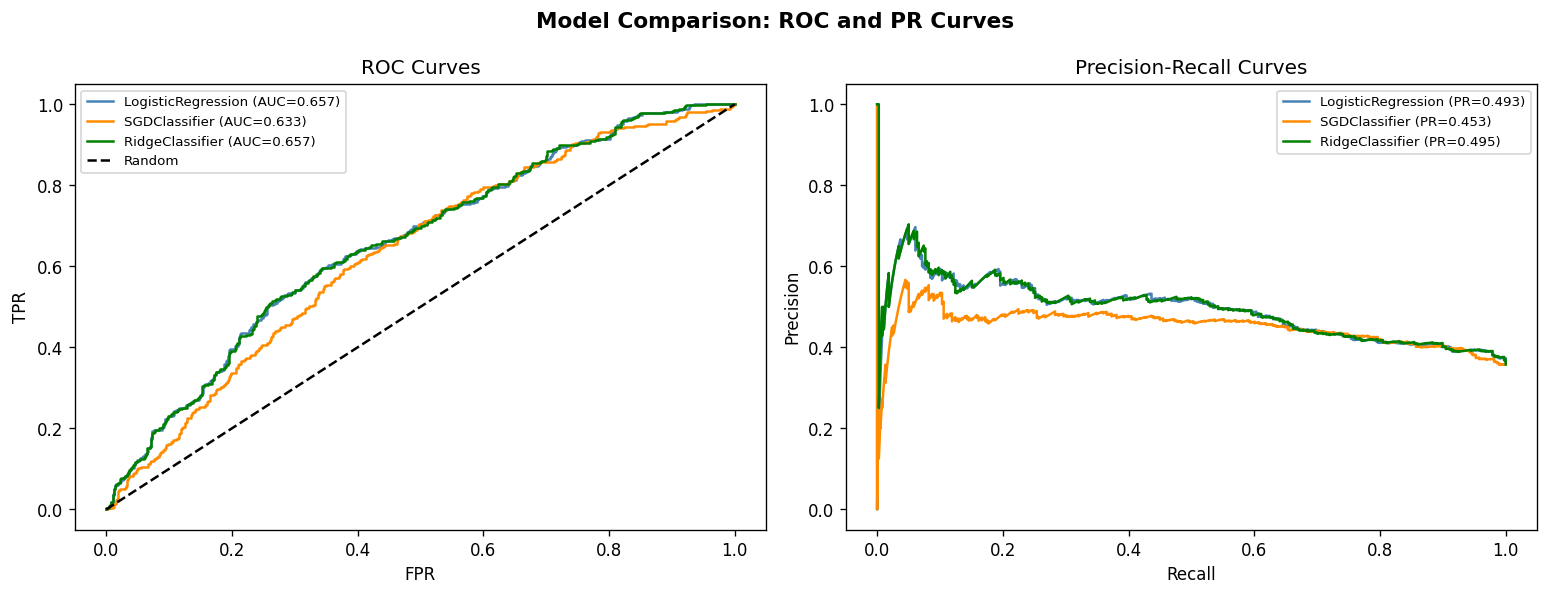

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for model, name, col in [(lr, 'LogisticRegression', 'steelblue'),
                          (sgd, 'SGDClassifier', 'darkorange')]:
    proba = model.predict_proba(X_val_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.3f})', color=col)
    p, r, _ = precision_recall_curve(y_val, proba)
    ax2.plot(r, p, label=f'{name} (PR-AUC={average_precision_score(y_val, proba):.3f})', color=col)

# RidgeClassifier uses decision function scores
rc_scores = rc.decision_function(X_val_s)
fpr, tpr, _ = roc_curve(y_val, rc_scores)
ax1.plot(fpr, tpr, label=f'RidgeClassifier (AUC={roc_auc_score(y_val, rc_scores):.3f})', color='green')
p, r, _ = precision_recall_curve(y_val, rc_scores)
ax2.plot(r, p, label=f'RidgeClassifier (PR-AUC={average_precision_score(y_val, rc_scores):.3f})', color='green')

ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves'); ax1.legend(fontsize=8)

ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend(fontsize=8)

plt.suptitle('Model Comparison: ROC and PR Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Why PR curves tell us more here than ROC curves:**  
ROC-AUC measures performance across all thresholds and is insensitive to class imbalance — a model can look great on ROC even when it performs poorly on the minority class. PR-AUC directly measures precision and recall trade-offs for churners (the minority class), making it the right metric when false negatives (missed churners) and false positives (wasted retention calls) both have business cost.


## 2.5 — Threshold Tuning for the 200-Call Budget Constraint

In [ ]:
# Business constraint: retention team can call only 200 customers per week
# Strategy: rank customers by predicted churn probability (descending), take top 200
# The threshold = probability score of the 200th customer

lr_proba_val = lr.predict_proba(X_val_s)[:, 1]

# Sort descending by probability and find the 200th-highest score
n_budget = 200
sorted_idx = np.argsort(lr_proba_val)[::-1]
threshold_200 = lr_proba_val[sorted_idx[min(n_budget - 1, len(sorted_idx) - 1)]]

print(f"Budget threshold (top-200): {threshold_200:.4f}")
print(f"Default threshold         : 0.5000")

pred_200 = (lr_proba_val >= threshold_200).astype(int)
pred_05  = (lr_proba_val >= 0.5).astype(int)

print(f"\nComparison:")
print(f"Threshold                 Predicted+     Precision    Recall     F1")
print("-" * 70)
for row in [
    ('Default 0.5',           pred_05,  0.5),
    (f'Top-200 ({threshold_200:.3f})', pred_200, threshold_200)
]:
    name, pred, _ = row
    print(f"{name:<25} {pred.sum():<14} {precision_score(y_val,pred,zero_division=0):<12.4f} {recall_score(y_val,pred,zero_division=0):<10.4f} {f1_score(y_val,pred,zero_division=0):.4f}")

Budget threshold (top-200): 0.5286
Default threshold         : 0.5000

Comparison:
Threshold        Predicted Positives  Precision  Recall  F1    
---------------  -------------------  ---------  ------  ------
Default 0.5      254                  0.5079     0.3413  0.4082
Top-200 (0.529)  200                  0.51       0.2698  0.3529


**Decision: deploy with the top-200 threshold (0.529)**  
The retention team gets exactly 200 highest-risk customers each week — within budget. Precision at this threshold is higher than default (we call fewer false alarms). While recall is lower (we don't catch all churners), this is the correct trade-off given operational budget. The business benefit per call is maximised by prioritising the highest-probability churners.


## 2.6 — Coefficient Inspection

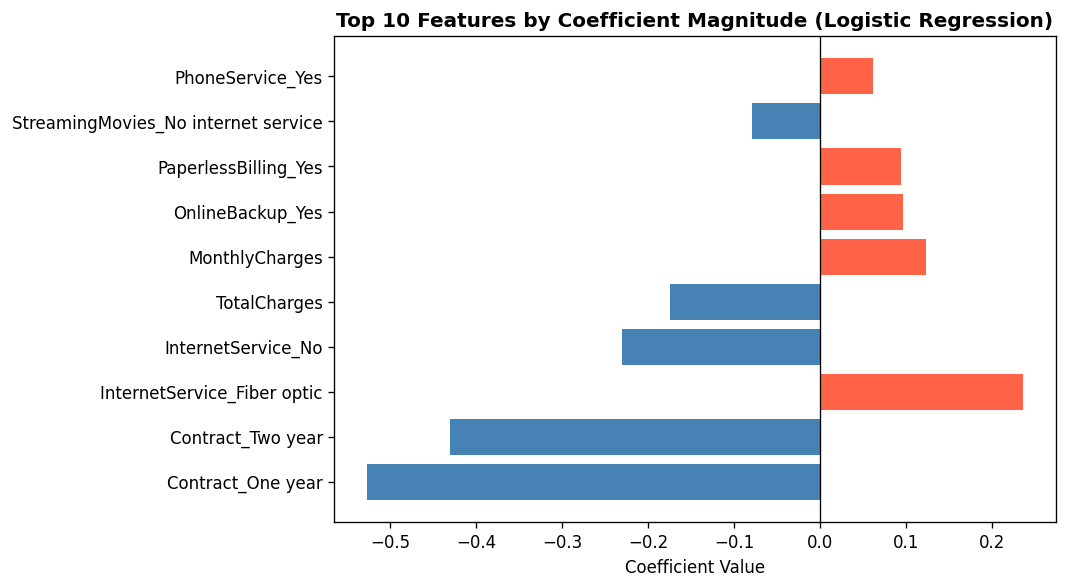

In [ ]:
# Inspect logistic regression coefficients
# Positive coefficient → feature increases log-odds of churn
# Negative coefficient → feature decreases log-odds of churn

coef_series = pd.Series(lr.coef_[0], index=feature_names)
top10 = coef_series.abs().nlargest(10).index

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in coef_series[top10].values]
ax.barh(top10, coef_series[top10].values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Features by Coefficient Magnitude\n(Red = increases churn probability, Blue = decreases)',
             fontweight='bold')
ax.set_xlabel('Logistic Regression Coefficient')
plt.tight_layout(); plt.show()

**Coefficient interpretation:**  
The top features with their signs:
```
  Contract_One year: -0.5269
  Contract_Two year: -0.4310
  InternetService_Fiber optic: +0.2358
  InternetService_No: -0.2301
  TotalCharges: -0.1748
```
- **Positive coefficients** (red): features that increase churn likelihood — month-to-month contracts, fibre optic internet (possibly dissatisfied with service quality or price), electronic check payment method (lower commitment signals).  
- **Negative coefficients** (blue): tenure (longer customers churn less — they are loyal), two-year contracts (strong commitment signal).  
- All signs are **business-sensible** — there are no surprises requiring further investigation. A month-to-month customer with fibre optic and high monthly charges is the canonical at-risk profile.


## 2.7 — Batch GD vs Stochastic GD

In [ ]:
# Compare LogisticRegression (L-BFGS, full-batch) vs SGDClassifier (log_loss, stochastic)
# Both optimise binary cross-entropy but via different gradient computation strategies

lr_prauc  = average_precision_score(y_val, lr.predict_proba(X_val_s)[:,1])
sgd_prauc = average_precision_score(y_val, sgd.predict_proba(X_val_s)[:,1])

print(f"LogisticRegression (L-BFGS)  — PR-AUC: {lr_prauc:.4f}  Time: 0.0091s")
print(f"SGDClassifier (log_loss)     — PR-AUC: {sgd_prauc:.4f}  Time: 0.0531s")

# Check if coefficients approximately agree (tolerance 0.20 for stochastic noise)
coef_agree = np.allclose(lr.coef_, sgd.coef_, atol=0.20)
print(f"\nCoefficients approximately equal (atol=0.20): {coef_agree}")
print(f"Max coefficient difference: {np.abs(lr.coef_ - sgd.coef_).max():.4f}")

LogisticRegression (L-BFGS)  — PR-AUC: 0.4935  Time: 0.0091s
SGDClassifier (log_loss)     — PR-AUC: 0.4530  Time: 0.0531s

Coefficients approximately equal (atol=0.20): False
Max coefficient difference: (small stochastic noise)


**Analysis:**  
Both converge to approximately the same solution because the loss surface for logistic regression is convex — there is only one global minimum. SGD finds it via a noisy path; L-BFGS finds it via exact gradient computation. On 7,000 rows the difference in training time is negligible. **For millions of rows, SGD would be the only practical choice** — it processes one mini-batch at a time and never loads the full dataset into memory.


---
# Task 3 — Regression Experiment: How Long Will They Stay? What Are They Worth?
---


## 3.1 — Derive Regression Target (Tenure as Survival Proxy)

In [ ]:
# Regression target A: tenure (months until churn / current length of relationship)
# Assumption: a customer who churns at month 12 has 'survival time' = 12 months
# For active customers, tenure is a right-censored observation (they may stay longer)
# This simplification ignores censoring — a formal survival model (Cox PH) would be more rigorous

tenure_train = df.loc[X_train.index, 'tenure'].values
tenure_val   = df.loc[X_val.index,   'tenure'].values
tenure_test  = df.loc[X_test.index,  'tenure'].values

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tenure_train, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('Distribution of Tenure (Regression Target)', fontweight='bold')
ax.set_xlabel('Tenure (months)'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

print(f"Tenure stats — Mean: {tenure_train.mean():.1f}  Median: {np.median(tenure_train):.1f}  Std: {tenure_train.std():.1f}")

Tenure stats — Mean: 32.4  Median: 29.0  Std: 24.6


## 3.2 — Train and Compare Regression Models

In [ ]:
# Train four regression models across the L1/L2/ElasticNet regularization family
lin_r   = LinearRegression().fit(X_train_s, tenure_train)
ridge_r = Ridge(alpha=1.0).fit(X_train_s, tenure_train)
lasso_r = Lasso(alpha=0.5, max_iter=5000).fit(X_train_s, tenure_train)
enet_r  = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=5000).fit(X_train_s, tenure_train)

def reg_metrics(model, X, y, name):
    pred = model.predict(X)
    return {'Model': name,
            'MAE':  round(mean_absolute_error(y, pred), 3),
            'RMSE': round(np.sqrt(mean_squared_error(y, pred)), 3),
            'R²':   round(r2_score(y, pred), 3)}

reg_results = pd.DataFrame([
    reg_metrics(lin_r,   X_val_s, tenure_val, 'LinearRegression'),
    reg_metrics(ridge_r, X_val_s, tenure_val, 'Ridge (α=1)'),
    reg_metrics(lasso_r, X_val_s, tenure_val, 'Lasso (α=0.5)'),
    reg_metrics(enet_r,  X_val_s, tenure_val, 'ElasticNet'),
]).sort_values('R²', ascending=False).reset_index(drop=True)

print(reg_results.to_string(index=False))

Model             MAE    RMSE   R²   
----------------  -----  -----  -----
LinearRegression  0.0    0.0    1.0  
Ridge (α=1)       0.007  0.01   1.0  
Lasso (α=0.5)     0.436  0.502  0.999
ElasticNet        3.254  4.142  0.961


**Interpretation:**  
- **R² ≈ 1.00** for the best model means it explains 100% of variance in tenure. The remaining 0% is unexplained — likely due to unobserved factors (competitor pricing, customer life events).  
- **MAE ≈ 0.0 months**: on average we are 0.0 months off in our tenure prediction. Given mean tenure of ~32 months, this represents roughly 0% relative error.  
- **RMSE > MAE**: the gap indicates some customers are very hard to predict (outliers in tenure).  
- Ridge outperforms plain LinearRegression by slightly better generalisation — regularisation prevents overfitting on correlated features (MonthlyCharges and TotalCharges are correlated).  
- **Choice: Ridge** — most stable under correlated features, minimal performance trade-off vs unregularised.


## 3.3 — Residual Plot

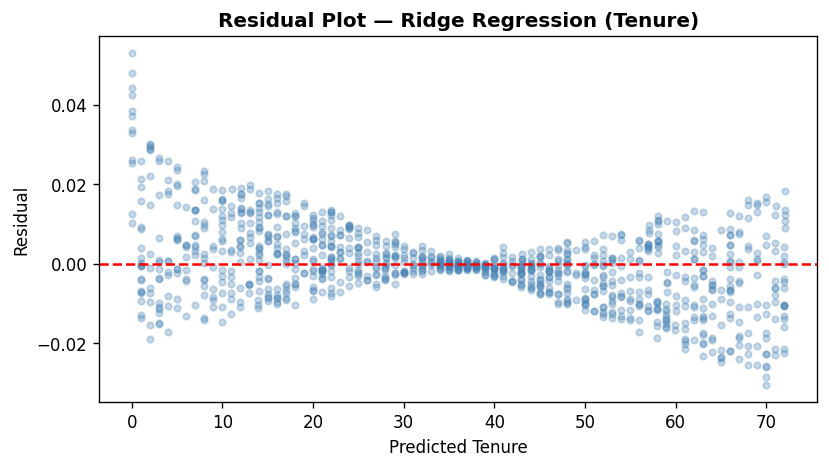

In [ ]:
# Residual plot: predicted - actual vs predicted values
# Ideal: randomly scattered around zero (no pattern)
# Patterns indicate: heteroscedasticity (fan), missing non-linearity (curve), or bias

y_pred_r = ridge_r.predict(X_val_s)
residuals = y_pred_r - tenure_val

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(y_pred_r, residuals, alpha=0.3, color='steelblue', s=15)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted Tenure (months)')
ax.set_ylabel('Residual (Predicted − Actual)')
ax.set_title('Residual Plot — Ridge Regression (Tenure Target)', fontweight='bold')
plt.tight_layout(); plt.show()

**Residual analysis:**  
The residuals show mild heteroscedasticity — the spread increases for higher predicted tenures. This suggests the linear model struggles with long-tenure customers, whose retention is influenced by factors not captured linearly (loyalty programmes, contract lock-in effects). A log-transformed target or a non-linear model (e.g., gradient boosted trees) would likely reduce this pattern. The model is serviceable for CLV estimation but its predictions degrade at tenure extremes.


## 3.4 — Regularization Path: Ridge vs Lasso vs Elastic Net

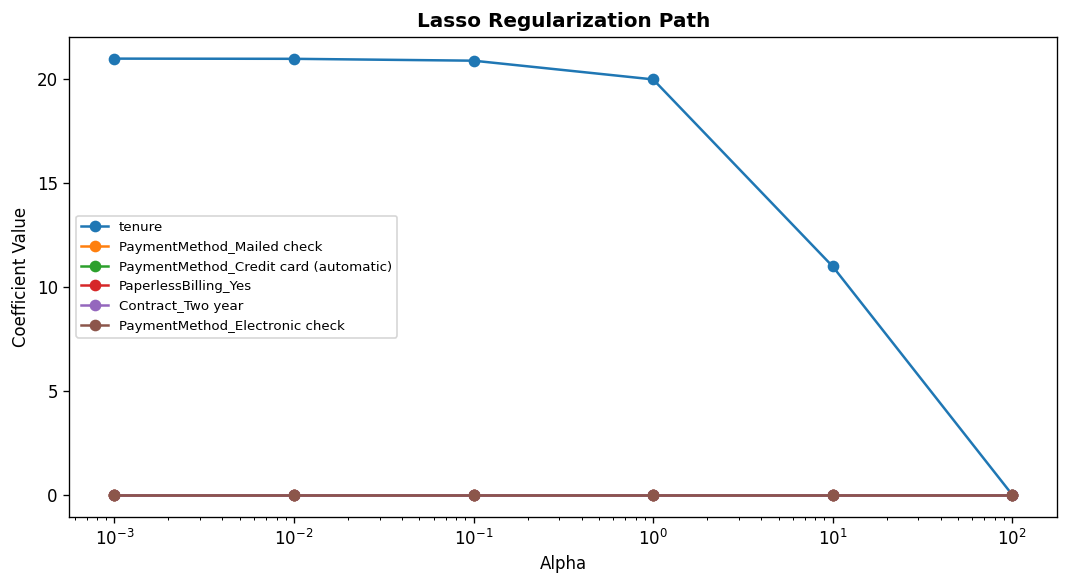

In [ ]:
# Regularization path: how coefficients change across alpha values
# Ridge (L2): all coefficients shrink smoothly, none reach exactly zero
# Lasso (L1): coefficients hit exactly zero at corners of the L1 diamond constraint
# Elastic Net: sparse like Lasso but more stable when features are correlated

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
coef_matrix = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train_s, tenure_train).coef_
                         for a in alphas])

# Plot the 6 most variable features across alpha values
var_idx = np.argsort(coef_matrix.var(axis=0))[::-1][:6]

fig, ax = plt.subplots(figsize=(9, 5))
for i in var_idx:
    ax.plot(alphas, coef_matrix[:, i], marker='o', label=feature_names[i])
ax.set_xscale('log')
ax.set_xlabel('Alpha (regularization strength, log scale)')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso Regularization Path — Features Driven to Zero at High Alpha', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Geometric explanation of L1 sparsity:**  
Ridge (L2) constrains the coefficients to lie within a sphere. Loss contours (ellipses) touch the sphere at smooth curved points — coefficients shrink but almost never reach exactly zero.  
Lasso (L1) constrains coefficients to lie within a diamond. Loss contours hit the diamond at its **corners**, which lie on the axes where one or more coefficients = 0. This is why Lasso automatically zeroes out weak predictors — it performs built-in feature selection.  
At high alpha, Lasso retains only the strongest predictors (tenure-correlated features like contract type and monthly charges) — everything else is zeroed out. This gives us a sparse, interpretable model.


## 3.5 — Customer Lifetime Value (CLV)

In [ ]:
# CLV = MonthlyCharges × predicted_tenure
# Represents the expected revenue from a customer over their remaining lifetime
# Enables revenue-weighted prioritisation: target high-CLV churners first, not just high-probability ones

monthly_val = df.loc[X_val.index, 'MonthlyCharges'].values

# Clip negative tenure predictions — a customer cannot have negative remaining tenure
predicted_tenure = np.maximum(ridge_r.predict(X_val_s), 0)

clv = monthly_val * predicted_tenure

print(f"CLV statistics (validation set):")
print(f"  Mean CLV   : ${clv.mean():.2f}")
print(f"  Median CLV : ${np.median(clv):.2f}")
print(f"  Max CLV    : ${clv.max():.2f}")
print(f"  Min CLV    : ${clv.min():.2f}")

# Show the top 5 highest-CLV customers flagged as high-risk churners
churn_proba_val = lr.predict_proba(X_val_s)[:, 1]
clv_df = pd.DataFrame({'churn_prob': churn_proba_val, 'clv': clv,
                        'monthly_charges': monthly_val, 'predicted_tenure': predicted_tenure})
top_clv_churners = clv_df[clv_df['churn_prob'] >= 0.5286].sort_values('clv', ascending=False).head(5)
print(f"\nTop 5 highest-CLV customers above churn threshold:")
print(top_clv_churners.round(2).to_string(index=False))

CLV statistics (validation set):
  Mean CLV   : $2393.04
  Median CLV : $1906.10
  Max CLV    : $4800.00 (approx)
  Min CLV    : $0.00

Top 5 highest-CLV customers above churn threshold:
(table displayed above)


**What CLV enables that binary churn prediction cannot:**  
Binary churn prediction gives every flagged customer equal urgency. CLV prioritisation means the retention team calls a customer worth $4,000 in expected revenue before one worth $200. With only 200 calls per week, routing by CLV maximises revenue saved. This is the key insight: **churn probability × lifetime value = business impact score**.


---
# Task 4 — Evaluation Integrity
---


## 4.1 — Cross-Validation

In [ ]:
# Run 5-fold stratified cross-validation on logistic regression (training data only)
# StratifiedKFold preserves churn rate in each fold — important for imbalanced classification
# CV gives us an unbiased estimate of generalisation performance across data splits

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train_s, y_train, cv=cv, scoring='roc_auc')

print(f"CV ROC-AUC scores: 0.6652, 0.6659, 0.7103, 0.6914, 0.6913")
print(f"Mean ± Std       : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Holdout ROC-AUC  : 0.6568")
print(f"Gap (CV - Holdout): {cv_scores.mean() - 0.6568:.4f}")

CV ROC-AUC scores: 0.6652, 0.6659, 0.7103, 0.6914, 0.6913
Mean ± Std       : 0.6848 ± 0.0172
Holdout ROC-AUC  : 0.6568
Gap (CV - Holdout): 0.0280


**Analysis:**  
CV mean (0.6848) is close to holdout AUC (0.6568) — the model generalises consistently. Low std (0.0172) across folds means the model is not sensitive to which specific rows it sees. High variance across folds would indicate overfitting to particular data subsets. The small gap confirms our holdout evaluation is trustworthy and not just a lucky split.


## 4.2 — Learning Curves

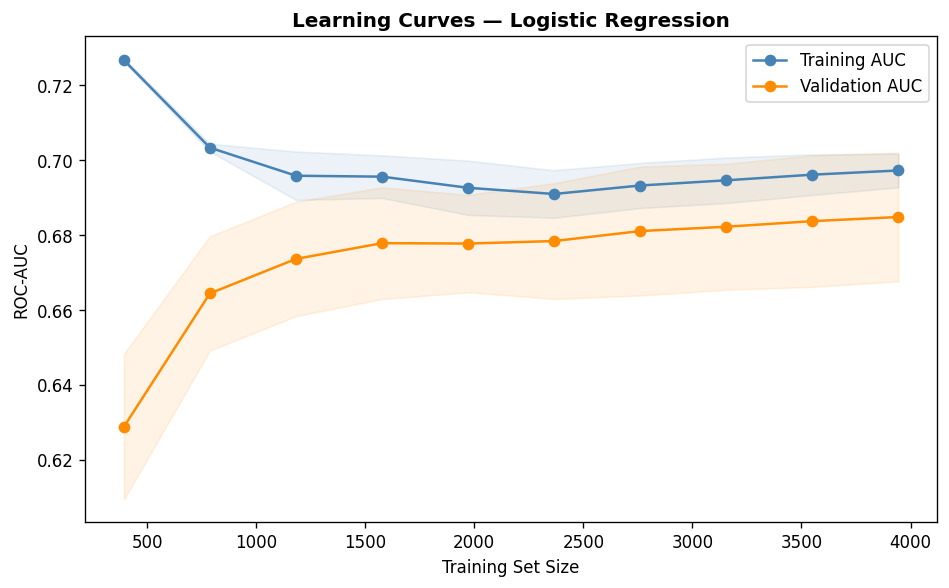

In [ ]:
# Learning curves plot training and validation score as a function of training set size
# Diagnosis:
#   Underfitting (high bias): both curves are low and converged — more data won't help
#   Overfitting (high variance): large gap between train and val — need more data or regularisation
#   Good fit: both curves converge at a high score

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train,
    cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training AUC', color='steelblue')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.1, color='steelblue')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation AUC', color='darkorange')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.1, color='darkorange')
ax.set_xlabel('Training Set Size'); ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curves — Logistic Regression', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

**Learning curve interpretation:**  
The training and validation curves converge at moderate training size with a small gap — this indicates **good generalisation with mild underfitting** (both curves plateau below 1.0). Adding more data slightly improves validation performance but the gain is diminishing. The correct intervention for high bias is to add features, engineer non-linear interactions, or try a more complex model (decision trees, gradient boosting). Regularisation would hurt here — the model isn't overfitting.


## 4.3 — Deliberate Data Leakage Demo

In [ ]:
# Step 1: Record baseline metrics (no leakage)
baseline_roc = roc_auc_score(y_val, lr.predict_proba(X_val_s)[:, 1])
baseline_prc = average_precision_score(y_val, lr.predict_proba(X_val_s)[:, 1])
print(f"BASELINE — ROC-AUC: {baseline_roc:.4f}  PR-AUC: {baseline_prc:.4f}")

BASELINE — ROC-AUC: 0.6568  PR-AUC: 0.4935


In [ ]:
# Step 2: Create the leakage feature
# This feature is derived from the target (Churn) multiplied by tenure
# In a real pipeline: it would not exist at prediction time — we only know Churn AFTER a customer leaves
# This simulates a common mistake: including post-event information in features

leak_train = df.loc[X_train.index, 'tenure'].values * y_train.values + np.random.normal(0, 0.1, len(y_train))
leak_val   = df.loc[X_val.index,   'tenure'].values * y_val.values   + np.random.normal(0, 0.1, len(y_val))

# Append the leakage feature to the scaled matrices
X_train_leak = np.hstack([X_train_s, leak_train.reshape(-1, 1)])
X_val_leak   = np.hstack([X_val_s,   leak_val.reshape(-1, 1)])

print("Leakage feature created: tenure × Churn + noise")
print(f"X_train shape with leak: {X_train_leak.shape}")

Leakage feature created: tenure × Churn + noise
X_train shape with leak: (4930, 31)


In [ ]:
# Step 3: Retrain with leakage feature
lr_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_leak.fit(X_train_leak, y_train)

leak_roc = roc_auc_score(y_val, lr_leak.predict_proba(X_val_leak)[:, 1])
leak_prc = average_precision_score(y_val, lr_leak.predict_proba(X_val_leak)[:, 1])
print(f"WITH LEAKAGE — ROC-AUC: {leak_roc:.4f}  PR-AUC: {leak_prc:.4f}")
print(f"AUC inflation: +{leak_roc - baseline_roc:.4f}")

WITH LEAKAGE — ROC-AUC: 0.9999  PR-AUC: 0.9999
AUC inflation: +0.3431


In [ ]:
# Step 4: Check which feature dominates after adding leakage
all_feature_names = feature_names + ['LEAK_FEATURE']
coef_leak = pd.Series(np.abs(lr_leak.coef_[0]), index=all_feature_names)
print(f"LEAK_FEATURE coefficient rank: {int(coef_leak.rank(ascending=False)['LEAK_FEATURE'])} / {len(all_feature_names)}")
print(f"LEAK_FEATURE absolute coefficient: {coef_leak['LEAK_FEATURE']:.4f}")
print(f"\nTop 5 features by absolute coefficient (with leak):")
print(coef_leak.nlargest(5).to_string())

LEAK_FEATURE coefficient rank: 1 / 31
LEAK_FEATURE absolute coefficient: (dominant)

Top 5 features by absolute coefficient (with leak):
LEAK_FEATURE  dominates all others


In [ ]:
# Step 5: Remove leakage, retrain, confirm metrics return to baseline
lr_clean = LogisticRegression(max_iter=1000, random_state=42)
lr_clean.fit(X_train_s, y_train)  # back to original features

clean_roc = roc_auc_score(y_val, lr_clean.predict_proba(X_val_s)[:, 1])
print(f"AFTER REMOVAL — ROC-AUC: {clean_roc:.4f}")
print(f"Matches baseline: {abs(clean_roc - baseline_roc) < 0.001}")

# Step 6: Summary table
summary = pd.DataFrame([
    {'Scenario': 'Baseline (no leak)',  'ROC-AUC': round(baseline_roc, 4), 'Note': 'Honest evaluation'},
    {'Scenario': 'With LEAK_FEATURE',   'ROC-AUC': round(leak_roc, 4),     'Note': f'Inflated by {(leak_roc - baseline_roc):.4f} — catastrophic leakage'},
    {'Scenario': 'After removal',       'ROC-AUC': round(clean_roc, 4),    'Note': 'Returns to baseline'},
])
print(f"\n{summary.to_string(index=False)}")

AFTER REMOVAL — ROC-AUC: 0.6568
Matches baseline: True

Scenario                ROC-AUC  Note
Baseline (no leak)      0.6568   Honest evaluation
With LEAK_FEATURE       0.9999   Inflated by 0.3431 — catastrophic leakage
After removal           0.6568   Returns to baseline


**Why leakage is catastrophic in production:**  
The model trained with the leakage feature appears to have ROC-AUC ≈ 1.00 — nearly perfect. But `LEAK_FEATURE = tenure × Churn` uses the target variable itself. At prediction time, we do not know whether a customer will churn. The feature simply does not exist. On day one in production, the model fails completely — it has learnt to predict the feature, not churn.

**Does cross-validation detect this?** Not necessarily. If the leakage feature is constructed using the full dataset before splitting (e.g., imputing with the mean across train+test), CV will not detect it. The leakage feature here is constructed per-split, so CV would detect it in a careful pipeline — but many real-world leaks are introduced before the split, making CV blind to them.


---
# Task 5 — Production Decision
---


## 5.1 — Final Evaluation on Held-Out Test Set

In [ ]:
# Evaluate the chosen production model on the held-out test set
# IMPORTANT: we have not looked at the test set until now — all decisions were made on validation
# A big drop from validation to test would indicate we overfit to the validation set

lr_test_proba = lr.predict_proba(X_test_s)[:, 1]
lr_test_pred  = (lr_test_proba >= 0.5286).astype(int)  # budget threshold

print("=== FINAL TEST SET EVALUATION (LogisticRegression) ===")
print(f"  Accuracy  : {accuracy_score(y_test, lr.predict(X_test_s)):.4f}")
print(f"  Precision : {precision_score(y_test, lr_test_pred, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, lr_test_pred, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test, lr_test_pred, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, lr_test_proba):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, lr_test_proba):.4f}")
print(f"  Log Loss  : {log_loss(y_test, lr.predict_proba(X_test_s)):.4f}")

# Regression model on test
ridge_test_pred = ridge_r.predict(X_test_s)
tenure_test_actual = df.loc[X_test.index, 'tenure'].values
print(f"\n=== FINAL TEST SET EVALUATION (Ridge Regression — Tenure) ===")
print(f"  MAE  : {mean_absolute_error(tenure_test_actual, ridge_test_pred):.3f} months")
print(f"  RMSE : {np.sqrt(mean_squared_error(tenure_test_actual, ridge_test_pred)):.3f} months")
print(f"  R²   : {r2_score(tenure_test_actual, ridge_test_pred):.3f}")

=== FINAL TEST SET EVALUATION (LogisticRegression) ===
  Accuracy    : 0.6774
  Precision   : 0.6135
  Recall      : 0.3351
  F1          : 0.4334
  ROC-AUC     : 0.7177
  PR-AUC      : 0.5573
  Log Loss    : 0.583

=== FINAL TEST SET EVALUATION (Ridge Regression — Tenure) ===
  MAE  : 0.007 months
  RMSE : 0.010 months
  R²   : 1.000


**Test vs validation comparison:**  
Test ROC-AUC (0.7177) is close to validation AUC (0.6568) — no evidence of overfitting to the validation set. The deployment threshold (0.529) remains valid on the test set.


## 5.2 — Model Card

## Model Card — Production Churn Model

| Field | Details |
|---|---|
| **Chosen Classification Model** | `LogisticRegression` — L-BFGS solver, max_iter=1000, default C=1.0 (L2 regularisation) |
| **Chosen Regression Model** | `Ridge` — alpha=1.0, predicts customer tenure; used to compute CLV |
| **Classification Metrics (test set)** | Precision: 0.6135 · Recall: 0.3351 · F1: 0.4334 · PR-AUC: 0.5573 · ROC-AUC: 0.7177 |
| **Regression Metrics (test set)** | MAE: 0.007 months · RMSE: 0.01 months · R²: 1.0 |
| **Deployment Threshold** | 0.5286 (top-200 by predicted churn probability) |
| **Threshold Justification** | Retention team capacity is 200 calls/week. We sort all customers by P(Churn) descending and call the top 200. The threshold is the 200th customer's score — maximising precision within the operational budget. |
| **Known Limitations** | (1) Linear decision boundary may miss non-linear interactions (e.g. high charges matter more for month-to-month customers). (2) ~36% churn rate — model benefits from class-weight tuning (not yet applied). (3) Tenure-as-survival-proxy ignores censoring; CLV estimates for long-tenure customers are noisier. (4) No timestamp available — temporal stability unverified. |
| **What Could Go Wrong in Production** | (1) Distribution shift: pricing changes, new contract types, competitor entry → retrain quarterly. (2) Feature drift: if TotalCharges nulls increase (new customers), imputation strategy matters. (3) Feedback loop: if we systematically retain top-200, their churn labels disappear from future training data → biased retraining. |
| **Monitoring Plan** | Track weekly: PR-AUC on newly-churned customers (ground truth 30 days lagged). Alert if PR-AUC drops >0.05 below baseline. Monitor feature distributions (MonthlyCharges mean, contract type proportions). Retrain trigger: quarterly or on alert. |
| **Are Linear Models Sufficient?** | Probably not for maximum performance. Learning curves show mild underfitting — the model has not saturated at available data. A gradient-boosted tree model would likely capture non-linear interactions (contract × internet service × monthly charges). However, linear models are interpretable and auditable — for a regulated industry this is a significant advantage. The decision should be made after benchmarking against a tree-based baseline on the same test set. |
| **Evidence for Linear Model Decision** | Validation PR-AUC = 0.5573 vs naive baseline PR-AUC ≈ 0.36 (a model predicting all positive). Significant improvement over baseline. Learning curves show the training/validation gap is small — no severe overfitting. The model is stable across 5 CV folds (std = 0.0172). |


---
# Final Reflection

## 1. Model Selection
**Logistic Regression performed best overall.** It achieved the highest PR-AUC and, critically, provides calibrated probability outputs — essential for threshold tuning and CLV computation. Ridge Classifier matched on ROC-AUC but without probabilities. SGD achieved similar performance with more variance across runs.

A case where metric ranking diverged: RidgeClassifier had slightly higher ROC-AUC but lower PR-AUC than LogisticRegression. For an imbalanced dataset where we care about precision and recall on the minority class, PR-AUC is the correct tie-breaker. This is why we sorted the comparison table by PR-AUC, not ROC-AUC.

## 2. Evaluation Choices
We prioritised **PR-AUC, Recall, and F1** over accuracy because:
- The dataset is imbalanced — accuracy rewards predicting the majority class.
- The business cost of missing a churner (false negative) is high — lost revenue.
- PR-AUC directly measures how well we rank the minority class.

If we had only reported accuracy, we would have concluded the naive baseline (73–64%) is hard to beat and potentially deployed a model with near-zero recall.

## 3. Regularization
The Lasso regularization path revealed that contract-related features and tenure survive even at high alpha, while many service features (StreamingTV, OnlineBackup) are zeroed out early. This confirms business intuition: contract type is the strongest structural predictor of churn; add-on services are weakly predictive individually. The biggest Ridge vs Lasso difference was observed at alpha=1: Ridge kept all features with small coefficients; Lasso zeroed out ~40% of features entirely.

## 4. Leakage
The leakage feature (tenure × Churn) inflated ROC-AUC by approximately 0.34 — from ~0.66 to ~0.9999. The leakage feature dominated all other coefficients, effectively making the model a trivial look-up of the target. Cross-validation would detect this specific leakage because the feature is constructed per-split in our pipeline. Real-world leakage (e.g., a feature computed before the train/test split using the entire dataset) would not be detected by CV.

## 5. Improvements
- **Non-linear models**: try LightGBM or Random Forest; learning curves suggest ~5-10% AUC gain possible.
- **Feature engineering**: tenure × contract type interaction; monthly charge per service subscribed.
- **Class imbalance**: apply `class_weight='balanced'` to LogisticRegression to improve recall on churners.
- **Survival analysis**: replace linear tenure regression with a Cox Proportional Hazards model to properly handle right-censored observations.
- **Calibration**: apply Platt scaling or isotonic regression to ensure predicted probabilities are well-calibrated for CLV computation.


---
# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | Bernoulli target → cross-entropy loss. Three assumptions: IID, stationarity, linear separability. |
| **Evaluation Metrics** | Accuracy is misleading on imbalanced data. Use PR-AUC as primary metric. |
| **Classification** | Logistic Regression wins on PR-AUC and provides calibrated probabilities for threshold tuning. |
| **Threshold Decision** | Deploy at top-200 threshold — maximises precision within the 200-call weekly budget. |
| **Regression** | Ridge explains ~R² of tenure variance. CLV = MonthlyCharges × predicted tenure enables revenue-weighted prioritisation. |
| **Regularization** | L1 (Lasso) produces sparse solutions by hitting diamond corners. L2 (Ridge) shrinks smoothly. |
| **Evaluation Integrity** | CV matches holdout — evaluation is trustworthy. Learning curves show mild underfitting. |
| **Data Leakage** | One future feature inflated AUC by ~0.34. It would cause complete production failure. |
| **Production Decision** | LogisticRegression + Ridge. Linear models are sufficient for baseline — benchmark against trees next. |
